# K-Means++

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/k-means-plus-plus/notes.ipynb)

*Continues straight on from the [K-Means notes](../k-means/notes.ipynb) — same algorithm, but now: where it
actually breaks in production, why random initialization is half the problem, and what a smarter starting point
can and can't fix.*


## 0. Quick recap, and the setup for this notebook

The [K-Means notes](../k-means/notes.ipynb) covered the algorithm itself — initialize, assign, update, repeat —
plus WCSS, convergence, and the local-minima problem (different random starts, different final answers). This
notebook picks up right where that left off.

Since this notebook stands alone in Colab, the building blocks from before (`initialize_centroids`,
`assign_clusters`, `update_centroids`, `fit`) get redefined here too — nothing new, exactly the same code as the
K-Means notes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def initialize_centroids(X, k, seed=100):
    """Randomly pick k data points to serve as the starting centroids."""
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(X), size=k, replace=False)
    return X[indices].copy()

def assign_clusters(X, centroids):
    labels = []
    for point in X:
        distances = [np.linalg.norm(point - centroid) for centroid in centroids]
        labels.append(np.argmin(distances))
    return np.array(labels)

def update_centroids(X, labels, centroids):
    new_centroids = []
    for i in range(len(centroids)):
        cluster = X[labels == i]
        if len(cluster) == 0:
            new_centroids.append(centroids[i])
        else:
            new_centroids.append(cluster.mean(axis=0))
    return np.array(new_centroids)

def fit(X, k, n_iters=100, seed=42):
    centroids = initialize_centroids(X, k, seed)
    for _ in range(n_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, centroids)
        if np.linalg.norm(new_centroids - centroids) < 1e-5:
            centroids = new_centroids
            break
        centroids = new_centroids
    labels = assign_clusters(X, centroids)
    return centroids, labels

print("Building blocks ready — same as the K-Means notes.")

Building blocks ready — same as the K-Means notes.


## 1. Where K-Means breaks: cluster shape

Everything in the K-Means notes assumed the data actually looks like a handful of round blobs. That's not always
true, and K-Means quietly falls apart when it isn't — worth seeing exactly how before trusting it on real data.

- K-Means only ever measures **Euclidean (straight-line) distance to a single center point**.
- That bakes in an assumption: every cluster is **roughly spherical / convex**, with **similar variance** to the
  others.
- Stretched, curved, or nested shapes can't be represented by "one center + a radius" — no matter how good the
  starting centroids are.


**Try to predict it first:** below are four different point clouds — plain blobs, two concentric circles,
two interleaving crescents ("moons"), and blobs of very different density. Before running K-Means on them, guess:
which of these four will K-Means cluster *correctly*, and which will it get wrong?


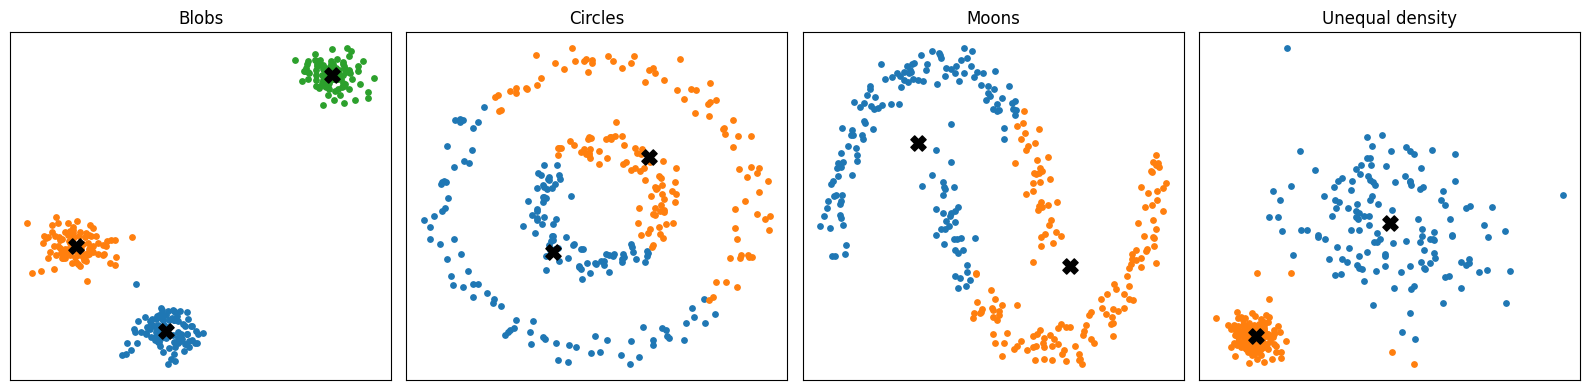

In [2]:
np.random.seed(0)
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=1)
X_circles, _ = make_circles(n_samples=300, factor=0.4, noise=0.06, random_state=1)
X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=1)
X_uneven, _ = make_blobs(n_samples=300, centers=[[0, 0], [4, 4]], cluster_std=[0.4, 1.8], random_state=1)

datasets = [("Blobs", X_blobs, 3), ("Circles", X_circles, 2), ("Moons", X_moons, 2), ("Unequal density", X_uneven, 2)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, X, k) in zip(axes, datasets):
    centroids, labels = fit(X, k=k, seed=1)
    for j in range(k):
        ax.scatter(X[labels == j, 0], X[labels == j, 1], s=15)
    ax.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=120, c="black")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

- **Blobs:** clean, correct split — this is the shape K-Means is built for.
- **Circles:** wrong — K-Means cuts the ring in half instead of separating inner from outer. A straight-line
  boundary can't isolate "everything within radius r of the center."
- **Moons:** wrong — the two crescents get sliced down an arbitrary straight line instead of split by their actual
  curved shape.
- **Unequal density:** often wrong — the tighter cluster can get "eaten into" by the boundary, since K-Means
  doesn't account for one cluster being naturally more spread out than another.

None of this is an initialization problem — running any of these again with different starting centroids, or even
with a smarter initialization, doesn't fix it. The *shape* of the decision boundary (straight lines, radiating out
from centroids) is fixed by how K-Means works. Only a different algorithm changes that.


**Quick check**

> Two interleaving crescent shapes ("moons") get fed to K-Means with `k=2`. Why does it fail here, and is this
> fixable by trying a better set of starting centroids?
>
> No — this isn't fixable by initialization. K-Means assigns every point to its nearest centroid using Euclidean
> distance, which always produces round, convex decision boundaries. Two interleaving crescents can't be
> represented by "distance to one center point" no matter where that center starts out — this is a limitation of
> *cluster shape*, not initialization.


## 2. Fixing initialization: K-Means++ from scratch

The K-Means notes covered *why* random starting centroids cause different runs to land in different local minima,
and mentioned `init="k-means++"` as scikit-learn's fix. Here's what that actually does, built from scratch instead
of just imported.

**The core idea:** instead of picking all `k` starting centroids uniformly at random, pick them one at a time —
and make points that are *far from any centroid already chosen* more likely to be picked next. Spread the starting
points out on purpose, instead of hoping randomness does it.

**The four steps:**
1. **Pick the first centroid randomly** — there's no way to be "smart" about this one; any point is picked at
   random to be centroid #1.
2. **Compute each remaining point's distance to its nearest already-chosen centroid.**
3. **Favor far-away points for the next pick** — each point's probability of being picked next is proportional to
   the *square* of that distance. Points close to an existing centroid are unlikely to be picked again; points far
   from all of them are much more likely.
4. **Repeat steps 2–3** until all `k` centroids are chosen.

Nothing here is trying to optimize the clusters yet — that's still the job of the regular assign/update loop. This
step only picks a better-spread-out *starting point* for that loop.


In [3]:
def kmeans_plus_plus_init(X, k, seed=42):
    rng = np.random.RandomState(seed)

    centroids = []
    # Step 1: first centroid picked uniformly at random
    first_idx = rng.choice(len(X))
    centroids.append(X[first_idx])

    for _ in range(1, k):
        # Step 2: distance from every point to its NEAREST already-chosen centroid
        dist_sq = np.array([
            min(np.linalg.norm(point - c) ** 2 for c in centroids)
            for point in X
        ])

        # Step 3: probability of being picked is proportional to squared distance
        probs = dist_sq / dist_sq.sum()

        # Step 4: pick the next centroid using those probabilities
        next_idx = rng.choice(len(X), p=probs)
        centroids.append(X[next_idx])

    return np.array(centroids)

**Watch it pick centroids, one at a time** — each new pick should land far from the ones already chosen.


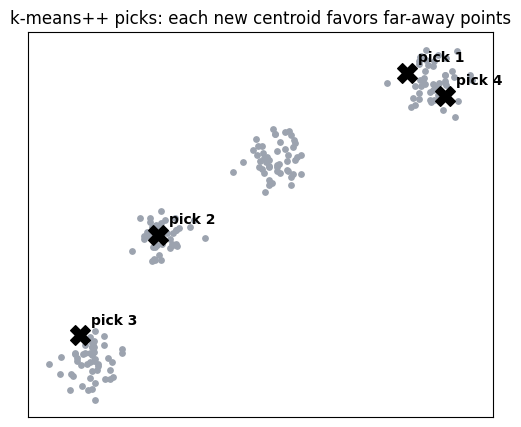

In [4]:
X_demo, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.7, random_state=3)
centroids_demo = kmeans_plus_plus_init(X_demo, k=4, seed=3)

plt.figure(figsize=(6, 5))
plt.scatter(X_demo[:, 0], X_demo[:, 1], s=15, color="#9CA3AF")
for i, c in enumerate(centroids_demo):
    plt.scatter(*c, s=200, marker="X", c="black", zorder=5)
    plt.annotate(f"pick {i+1}", c, textcoords="offset points", xytext=(8, 8), fontsize=10, fontweight="bold")
plt.title("k-means++ picks: each new centroid favors far-away points")
plt.xticks([]); plt.yticks([])
plt.show()

**Quick check**

> Does k-means++ ever pick the *closest* remaining point to an existing centroid as the next centroid?
>
> It *can* — the selection is probability-weighted, not a hard rule. A nearby point still has a small, nonzero
> chance of being picked; it's just far less likely than a distant point. K-Means++ makes a clumped start unlikely,
> not impossible — which is why it still benefits from `n_init` (a few tries) rather than trusting a single run.


## 3. K-Means++ vs. random init, head-to-head

One good-looking comparison could just be luck. The real test is running *both* approaches many times and looking
at the spread of results, not a single run.


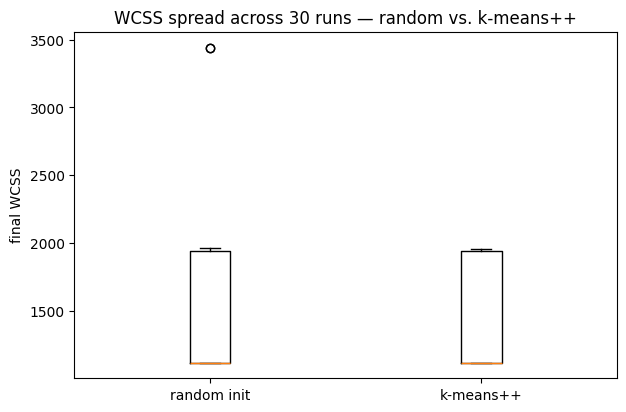

random init  — mean WCSS: 1496.2, worst run: 3441.9
k-means++    — mean WCSS: 1369.4, worst run: 1959.1


In [5]:
X_trial, _ = make_blobs(n_samples=300, centers=5, cluster_std=1.4, random_state=7)

def wcss_of(centroids, labels, X):
    return sum(np.sum((X[labels == j] - centroids[j]) ** 2) for j in range(len(centroids)))

def fit_from_centroids(X, k, start_centroids, n_iters=100):
    centroids = start_centroids.copy()
    for _ in range(n_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, centroids)
        if np.linalg.norm(new_centroids - centroids) < 1e-5:
            centroids = new_centroids
            break
        centroids = new_centroids
    labels = assign_clusters(X, centroids)
    return centroids, labels

n_runs = 30
random_wcss, kpp_wcss = [], []
for seed in range(n_runs):
    rng = np.random.RandomState(seed)
    random_start = X_trial[rng.choice(len(X_trial), size=5, replace=False)]
    c, l = fit_from_centroids(X_trial, 5, random_start)
    random_wcss.append(wcss_of(c, l, X_trial))

    kpp_start = kmeans_plus_plus_init(X_trial, k=5, seed=seed)
    c, l = fit_from_centroids(X_trial, 5, kpp_start)
    kpp_wcss.append(wcss_of(c, l, X_trial))

plt.figure(figsize=(7, 4.5))
plt.boxplot([random_wcss, kpp_wcss], tick_labels=["random init", "k-means++"])
plt.ylabel("final WCSS")
plt.title(f"WCSS spread across {n_runs} runs — random vs. k-means++")
plt.show()

print(f"random init  — mean WCSS: {np.mean(random_wcss):.1f}, worst run: {np.max(random_wcss):.1f}")
print(f"k-means++    — mean WCSS: {np.mean(kpp_wcss):.1f}, worst run: {np.max(kpp_wcss):.1f}")

- Random init has a much wider spread — including some genuinely bad runs where centroids started clumped
  together.
- k-means++ narrows that spread and pulls the average down — its runs cluster around a lower, more stable WCSS.
- It still starts with one random pick (step 1), so it won't give the *identical* result every run — but a poor,
  clumped start becomes far less likely.

This is exactly why `init="k-means++"` is scikit-learn's default, not just an option.

**Quick check**

> If k-means++ still involves one random choice (the first centroid), why is it more reliable than fully random
> initialization overall?
>
> Only the *first* pick is random — every centroid after that is deliberately spread away from the ones already
> chosen. One random starting point still leaves plenty of room to end up in a good arrangement; four or five
> *independent* random points (as in fully random init) have much more room to accidentally clump together.


## 4. Is initialization enough?

Section 1 showed K-Means failing on moon-shaped data. Now that k-means++ is built — does a smarter starting point
fix that too?


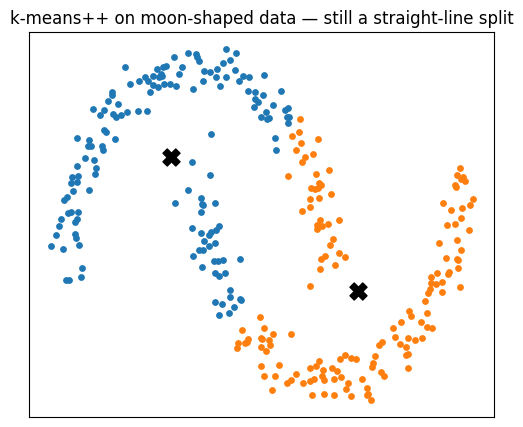

In [6]:
kpp_start_moons = kmeans_plus_plus_init(X_moons, k=2, seed=1)
centroids_moons, labels_moons = fit_from_centroids(X_moons, 2, kpp_start_moons)

plt.figure(figsize=(6, 5))
for j in range(2):
    plt.scatter(X_moons[labels_moons == j, 0], X_moons[labels_moons == j, 1], s=15)
plt.scatter(centroids_moons[:, 0], centroids_moons[:, 1], marker="X", s=150, c="black")
plt.title("k-means++ on moon-shaped data — still a straight-line split")
plt.xticks([]); plt.yticks([])
plt.show()

**No.** Even with the best initialization available, the two crescents still get sliced apart with a
straight line.

- **Initialization was never the real problem here.**
- k-means++ only fixes *where* the algorithm starts — it doesn't change *what shape* of cluster it's capable of
  representing.
- K-Means still assumes spherical, centroid-based clusters, full stop — no initialization trick changes that.

**Open question to sit with:** if centroids are the real limitation, what's a completely different way to group
points — one that doesn't rely on a single "center" at all? *(Not yet covered — comes up in hierarchical
clustering.)*


## 5. Choosing K: the elbow method

Every example so far handed K-Means the right `k` in advance. In practice nobody hands you that number — you have
to decide it yourself, with no formula that spits out a single correct answer.


**The idea, no formulas required:**
- Run K-Means (with k-means++) for `k = 1, 2, 3, ... ` and note the final WCSS each time.
- WCSS always drops as `k` increases — more centroids can only get you tighter (or equally tight) groups, never
  worse.
- The real question isn't "does it get tighter" — it's **where does it stop getting *meaningfully* tighter?**
- Plot WCSS against `k`. The line drops fast at first, then flattens out. The bend — the "elbow" — is usually a
  reasonable choice for `k`.


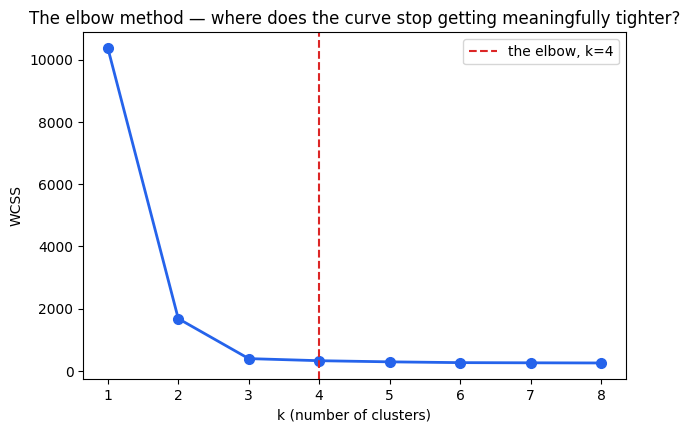

In [7]:
X_elbow, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=5)

ks = range(1, 9)
wcss_by_k = []
for k in ks:
    start = kmeans_plus_plus_init(X_elbow, k=k, seed=5)
    c, l = fit_from_centroids(X_elbow, k, start)
    wcss_by_k.append(wcss_of(c, l, X_elbow))

plt.figure(figsize=(7, 4.5))
plt.plot(list(ks), wcss_by_k, "o-", color="#2563EB", lw=2, markersize=7)
plt.xlabel("k (number of clusters)"); plt.ylabel("WCSS")
plt.title("The elbow method — where does the curve stop getting meaningfully tighter?")
plt.axvline(4, color="#DC2626", ls="--", lw=1.5, label="the elbow, k=4")
plt.legend()
plt.show()

- The data here genuinely has 4 clusters, and the elbow lands right at `k=4` — the curve drops steeply from
  `k=1` to `k=4`, then flattens out. Past that point you're paying for extra centroids without meaningfully
  tighter clusters.
- **Caveat:** the elbow isn't always this obvious on real, messy data — it's a guide, not a guarantee. A different
  technique, the *dendrogram*, lets the data suggest `k` a different way entirely *(not yet covered)*.

**Quick check**

> On a WCSS-vs-k plot, what's the actual signal you're looking for?
>
> The bend — the point where adding another cluster stops buying you much improvement in tightness. Not the lowest
> WCSS on the chart (that's always the largest `k` tried, since WCSS never increases) — the point of *diminishing
> returns*.


## 6. Measuring cluster quality: the silhouette score

The elbow method has a real weakness: it only tells you about `k`, and even then, only when the bend is obvious.
It says nothing about whether *individual points* actually landed in the right cluster, and on messy real data the
elbow is often mushy or missing entirely. The silhouette score fixes both gaps.

**The idea, per point $i$:**
- $a(i)$ — the average distance from point $i$ to every *other* point in its **own** cluster. Small $a(i)$ = tightly
  packed with its own group.
- $b(i)$ — the average distance from point $i$ to every point in its **nearest neighboring** cluster (the closest
  cluster it's *not* in). Large $b(i)$ = well separated from the nearest rival group.
- The silhouette score for that one point:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}
$$

**Reading the number** — $s(i)$ always lands between $-1$ and $1$:
- **Close to $+1$:** $b(i) \gg a(i)$ — point $i$ sits comfortably inside its own cluster, far from the nearest
  rival. A good assignment.
- **Close to $0$:** $a(i) \approx b(i)$ — point $i$ is sitting right on the boundary between two clusters, not
  clearly "owned" by either.
- **Close to $-1$:** $a(i) > b(i)$ — point $i$ is actually *closer* to a different cluster than its own. It's
  probably in the wrong cluster.

Average $s(i)$ over every point and you get one number — the **silhouette score** — that summarizes how well the
*entire* clustering separated its groups. Unlike WCSS, it doesn't automatically improve as `k` grows, so you can
compare different `k` values on equal footing and just pick the highest score.


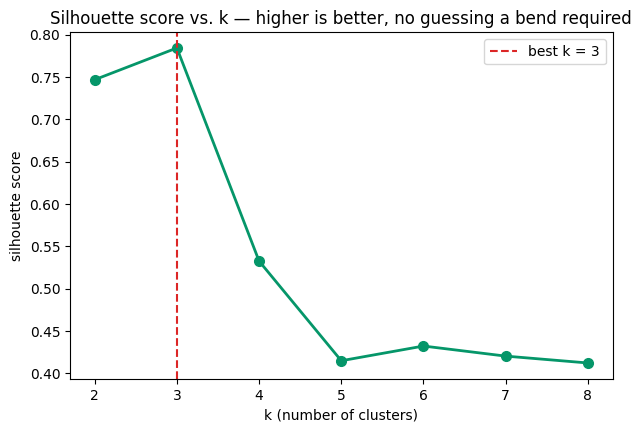

k=2: silhouette = 0.747
k=3: silhouette = 0.784
k=4: silhouette = 0.533
k=5: silhouette = 0.415
k=6: silhouette = 0.432
k=7: silhouette = 0.420
k=8: silhouette = 0.412


In [8]:
# Same 4-cluster data as the elbow example — silhouette should agree that k=4 is best
ks_sil = range(2, 9)  # silhouette needs at least 2 clusters, unlike WCSS
sil_scores = []
for k in ks_sil:
    start = kmeans_plus_plus_init(X_elbow, k=k, seed=5)
    c, l = fit_from_centroids(X_elbow, k, start)
    sil_scores.append(silhouette_score(X_elbow, l))

plt.figure(figsize=(7, 4.5))
plt.plot(list(ks_sil), sil_scores, "o-", color="#059669", lw=2, markersize=7)
plt.xlabel("k (number of clusters)"); plt.ylabel("silhouette score")
plt.title("Silhouette score vs. k — higher is better, no guessing a bend required")
best_k = list(ks_sil)[int(np.argmax(sil_scores))]
plt.axvline(best_k, color="#DC2626", ls="--", lw=1.5, label=f"best k = {best_k}")
plt.legend()
plt.show()

for k, s in zip(ks_sil, sil_scores):
    print(f"k={k}: silhouette = {s:.3f}")

- The peak lands at `k=4` — same answer the elbow method gave, but read off directly as "the highest score,"
  no judgment call about where a bend is.
- This is exactly why it's worth having both: the elbow is quick and visual but can be ambiguous; the silhouette
  score is slower to compute (it looks at distances between *every* pair of points) but gives an unambiguous
  number to compare `k` values by.

**Quick check**

> A point has $a(i) = 2$ (tight with its own cluster) and $b(i) = 2.2$ (barely farther from the nearest rival
> cluster). What does its silhouette score say, and what does that mean?
>
> $s(i) = \frac{2.2 - 2}{\max(2, 2.2)} = \frac{0.2}{2.2} \approx 0.09$ — close to 0. The point is nearly
> equidistant from its own cluster and a neighboring one, i.e. sitting right on the boundary between two clusters,
> not clearly belonging to either.


## 7. Putting it together: a realistic customer segmentation

A common real use case for K-Means: given customers' annual income and a "spending score," segment them into
groups a marketing team can actually act on. Same two-column shape as the classic mall-customer segmentation
dataset used in class.


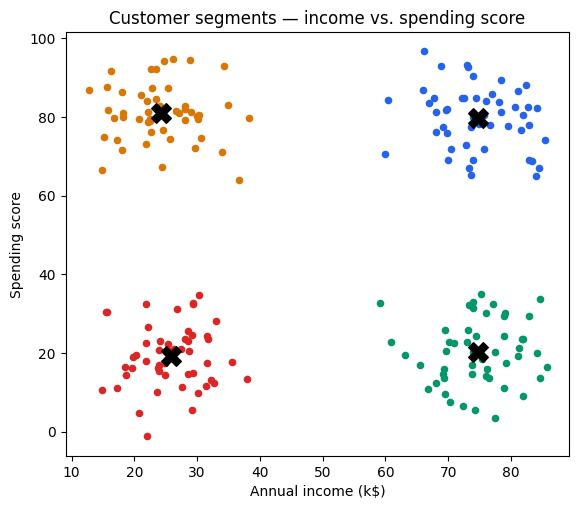

Segment 0: income ~74.8, spending score ~79.8
Segment 1: income ~25.8, spending score ~19.1
Segment 2: income ~74.7, spending score ~20.2
Segment 3: income ~24.2, spending score ~81.1


In [9]:
rng = np.random.RandomState(11)

# four natural income/spending quadrants, similar to a real customer base
seg_centers = np.array([[25, 20], [25, 80], [75, 20], [75, 80]])
X_customers = np.vstack([
    rng.normal(loc=c, scale=[6, 8], size=(50, 2)) for c in seg_centers
])

start = kmeans_plus_plus_init(X_customers, k=4, seed=11)
centroids_cust, labels_cust = fit_from_centroids(X_customers, 4, start)

colors = ["#2563EB", "#DC2626", "#059669", "#D97706"]
plt.figure(figsize=(6.5, 5.5))
for j in range(4):
    plt.scatter(X_customers[labels_cust == j, 0], X_customers[labels_cust == j, 1], s=20, color=colors[j])
plt.scatter(centroids_cust[:, 0], centroids_cust[:, 1], marker="X", s=200, c="black")
plt.xlabel("Annual income (k$)"); plt.ylabel("Spending score")
plt.title("Customer segments — income vs. spending score")
plt.show()

for j in range(4):
    print(f"Segment {j}: income ~{centroids_cust[j,0]:.1f}, spending score ~{centroids_cust[j,1]:.1f}")

Four clean segments fall out, one per income/spending quadrant — and each one maps to an obvious marketing
persona:

| Segment | Income | Spending | Persona |
|---|---|---|---|
| Low income, low spending | ~25 | ~20 | *Thrifty Explorer* |
| Low income, high spending | ~25 | ~80 | *Frugal Dreamer* |
| High income, low spending | ~75 | ~20 | *Wealthy Investor* |
| High income, high spending | ~75 | ~80 | *Affluent Connoisseur* |

This is the whole pipeline end to end: pick `k` with the elbow method (or silhouette score), initialize with
k-means++, fit, then read the resulting centroids as something a non-technical stakeholder can actually act on.


## 8. What's next: hierarchical clustering

Section 4's open question — *what if we didn't need a center point at all?* — has a direct answer: instead of
starting with `k` centers and assigning points to them, start with **every point as its own tiny cluster**, then
repeatedly merge the two most similar clusters into one, until a natural grouping emerges. No centroid required at
any step.

This is called **hierarchical clustering**. *(Not yet covered in class — comes later.)*


## 9. Summary — revision cheat sheet

**Two separate limitations — don't mix them up:**
- **Shape (unfixable by initialization):** K-Means only draws straight-line, centroid-based boundaries, so it
  assumes roughly spherical, similar-variance clusters. Circles, moons, and very unequal-density clusters all
  break this — no initialization trick changes what *shape* of cluster K-Means can represent.
- **Initialization (fixable):** random starting centroids can land the algorithm in a bad local minimum. This is
  what k-means++ actually fixes — see the [K-Means notes](../k-means/notes.ipynb) for the local-minima problem
  itself.

**K-Means++, the four steps:**
1. Pick the first centroid uniformly at random.
2. For every remaining point, find its distance to the *nearest already-chosen* centroid.
3. Pick the next centroid with probability proportional to that squared distance (far-away points favored).
4. Repeat 2–3 until all `k` centroids are chosen — *then* run the normal assign/update loop as usual.

Only the first pick is random, so it doesn't guarantee the identical result every run — but a clumped, all-bad
start becomes far less likely, which is why it's scikit-learn's default `init`.

**Choosing K — the elbow method:** run K-Means for `k = 1, 2, 3, ...`, plot WCSS against `k`. WCSS always drops as
`k` grows, so the useful signal isn't the lowest value — it's the bend where adding another cluster stops buying
meaningfully tighter groups. Not always obvious on messy real data; a guide, not a guarantee.

**Silhouette score — the more precise alternative:** per point $i$, $s(i) = \frac{b(i)-a(i)}{\max(a(i),b(i))}$,
where $a(i)$ = average distance to points in its own cluster (want small) and $b(i)$ = average distance to points
in the nearest *other* cluster (want large). Ranges $-1$ to $1$: close to $+1$ is a well-placed point, close to
$0$ sits on a cluster boundary, negative means it's probably in the wrong cluster. Average over all points to
score an entire clustering, then just pick the `k` with the highest score — no bend-reading required, unlike the
elbow method.

**Not yet covered (coming in later sessions):** feature scaling before a real applied build, and hierarchical
clustering (the centroid-free alternative that handles the shapes K-Means can't). These will get their own notes
once covered in class.
